# An analysis pipeline to compute the PADF from a diffraction dataset

### This notebook contains the full analysis pipeline for analysising a scanning convergent beam data set and producing the padf

In [4]:
%reload_ext autoreload
%autoreload 2

import os
import subprocess
#import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import register_patterns_mp as rpm
import importlib
import pathlib
from datetime import date
importlib.reload(rpm)
%matplotlib qt

def pstr( path, append_text=""):
    return str( (path/append_text).resolve())

### STEP 1: Which dataset do you want to analyse? (give the name of the folder containing the data)

In [5]:
dz = 500 # detector distance
rootpath = pathlib.Path( "./demo")


# the path containing the diffraction patterns
datapath = rootpath / "output/diff"

# Path to all the config files for correlation, PADF and plotting
# Parameters can be changed in the config files
configpath = rootpath / "configs"

sample = "hex"

# the path where the results will be saved
outpath = rootpath / "jupyter-results"
outpath = outpath / sample
if not os.path.exists(outpath):
    os.makedirs(outpath)

fext = ".npy"

# Nominal centre of the diffraction pattern in pixels (doesn't have to be exact)
yin, xin = 256, 256

### STEP 2: Recentre the data### STEP 2.1: Find the centre of the reference frame

In [6]:
recencls = rpm.recenter_diffraction_patterns(sample,dpath=datapath,outpath=outpath,
                                             recenpath=outpath / "recentred_data",rebinflag=False,outputshifted=False,fext=fext)


recencls.recentre_patterns(yin, xin, npatterns=16)
print("finished recentering")
plt.imshow( recencls.imagesum**0.3)

<class 'str'>
 Number of filenames found: 1000
/Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/output/diff/*.npy
Main threading loop 0
Main threading loop 1
Main threading loop 2
Main threading loop 3
joining
finished recentering


### STEP 2.2 - Input reference centre positon & recentre data to array centre
### USER INPUT REQUIRED FOR EXPERIMENTAL DATA. 
#### (for simulated demo, no change is required)

#### Use the previous image to determine the centre of the diffraction pattern
#### Enter the new center x and y values in the next plot, then run the cell to recentre all diffraction patterns. 
#### The diffraction patterns will be rebinned and saved on this run through. If it has worked, the centre of the diffraction patterns should be the centre of the array


In [7]:
newyin, newxin = 256,256
recencls.nthreads = 8
recencls.rebinflag = False
recencls.outputshifted = False
recencls.recentre_patterns(newyin, newxin, npatterns=-1) # npatterns<1 means use all the diffraction patterns
 

Main threading loop 0
Main threading loop 1
Main threading loop 2
Main threading loop 3
Main threading loop 4
Main threading loop 5
Main threading loop 6
Main threading loop 7
joining


### STEP 2.3: Check that the recentred data has the centre of the diffraction pattern in the middle of the array;
#### If not, then redo the centering steps above

In [37]:
plt.imshow( recencls.imagesum)

### STEP 3.1: MASKING
### Create a mask for the data by uncommenting/adding lines that set mask pixels to 0
#### If no mask is required, please run this cell with the mask set to 1 everywhere

<IPython.core.display.Javascript object>


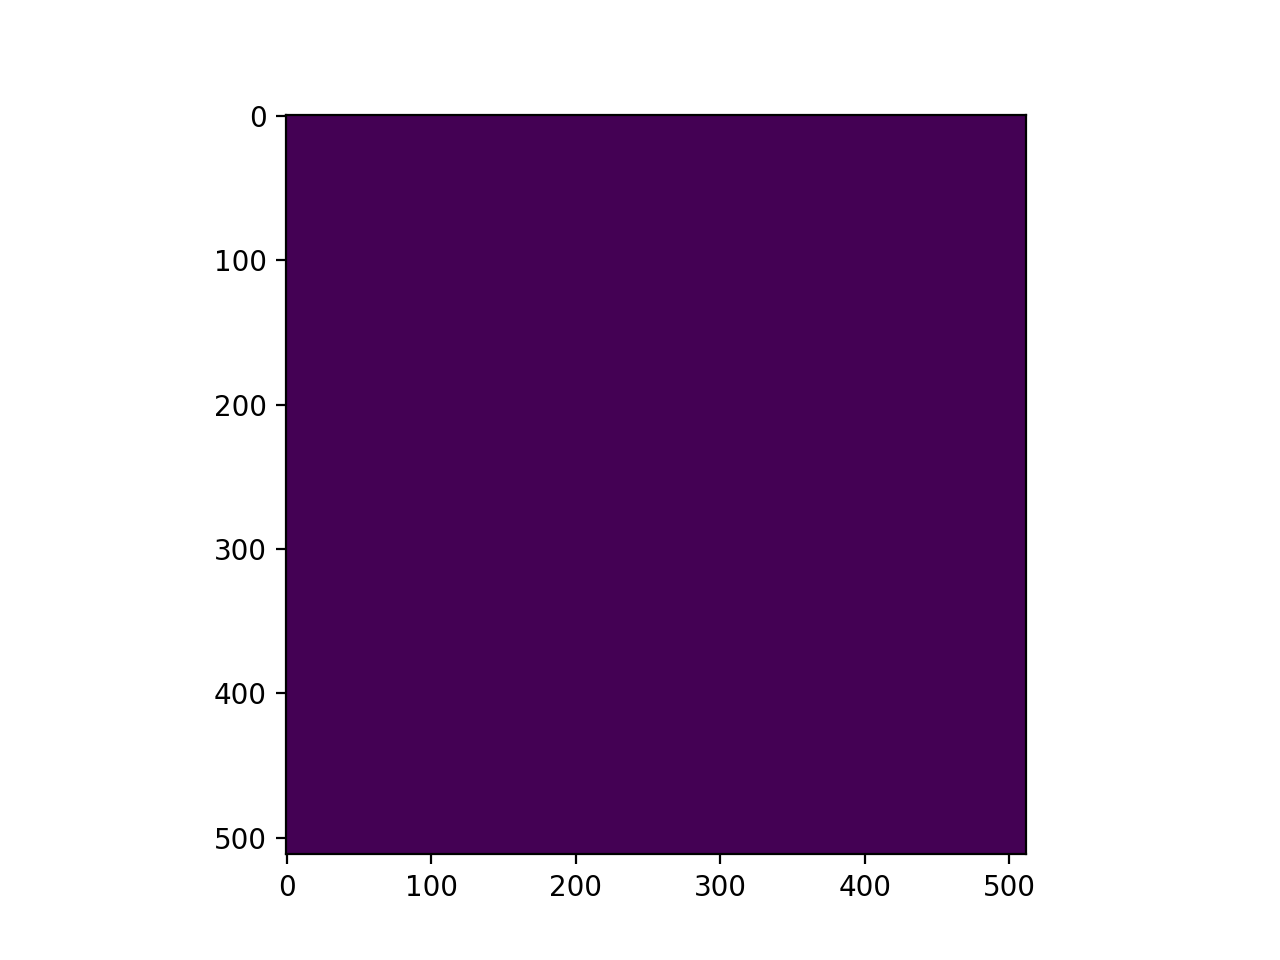

<IPython.core.display.Javascript object>


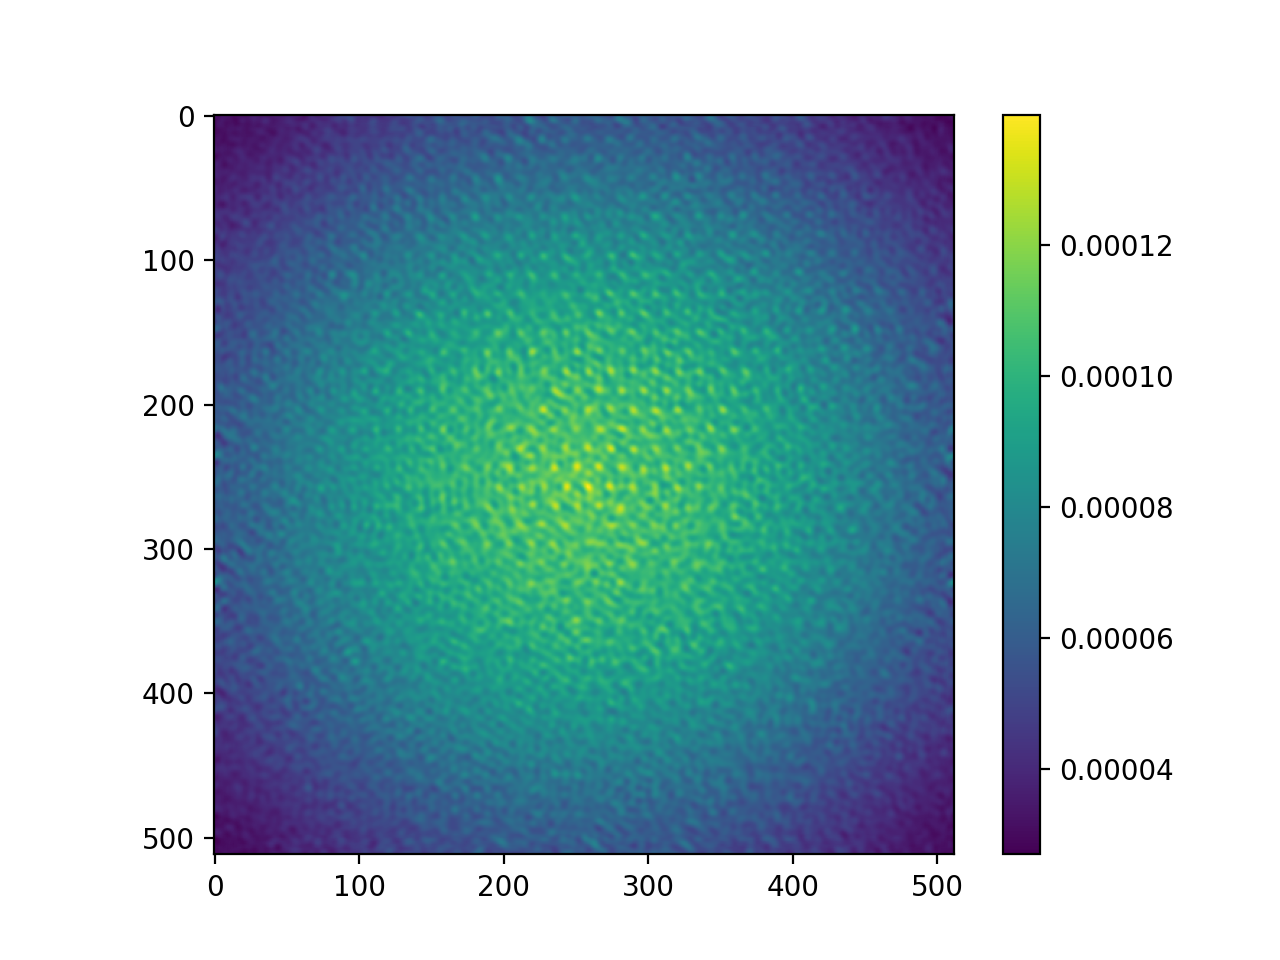

In [8]:
dpath = pathlib.Path(outpath) / "registration"
dname = pstr(dpath , f"{sample}imav.npy")
datetag = date.today()
datetag = datetag.strftime("%d%m%Y")
mpath = pathlib.Path(outpath) / "masks"
if not os.path.exists( mpath): os.makedirs(mpath)
mask_fname =  pstr(mpath, f"mask{datetag}ff.npy")   # this is the name of your mask file CHANGE THIS SO YOU DON'T OVERWRITE THE LAST ONE!!!!

data = np.load(dname)
mask = np.ones(data.shape)
#mask[:,37:43] = 0
#mask[:,247:256] = 0
plt.imshow(mask)
plt.figure()
plt.imshow(data*mask)
#plt.clim([-1000,1000])
plt.colorbar()
np.save(mask_fname, mask)

###STEP 4: CORRELATE DIFFRACTION PATTERNS
### STEP 4.1: Set up the directories for correlation & PADF output
###           Correlate all the diffraction patterns

In [9]:
configfile = pstr( configpath, "config_hex_corr.txt")
padfoutpath = outpath / "padf_output/"
if not os.path.isdir(padfoutpath): os.makedirs(padfoutpath)
if recencls.outputshifted:
    samplepath = recencls.outpath2 / "\*.npy"
else:
    samplepath = datapath / "\*.npy"
tag = sample

# The main correlation calculation is here
npatterns = 100
flags = f"--outpath {pstr(padfoutpath)} --samplepath {str(samplepath)} --tag {tag} --maskname {mask_fname} --dz {dz*0.001} --npatterns {npatterns}"
print("About to start correlating diffraction patterns...")
print( "Flags:")
print( flags )
app = pstr(pathlib.Path("./difftocorr.py"))
result = subprocess.run( f"python {app} --config {configfile} {flags}", shell=True) #, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT) 

About to start correlating diffraction patterns...
Flags:
--outpath /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output --samplepath demo/output/diff/\*.npy --tag hex --maskname /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/masks/mask21052026ff.npy --dz 0.5 --npatterns 100

-------------------------------------------------------------------------
 difftocorr.py : calculate correlation function from diffraction patterns
-------------------------------------------------------------------------
pypadf version  0.5.2
 

config file name: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/configs/config_hex_corr.txt

Performing Correlations
Background estimate?   False
Difference correlation?  False


nchunk : 25
thread 0; number of patterns 25
thread 1; number of patterns 25
thread 2; number of patterns 25
thread 3; number of patterns 25
Main threading

### STEP 4.2: Check the q-space correlation function


pypadf version  0.5.2
 

config file name: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/configs/config_hex_corrplot.txt
Plotting : /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output/hex_a_correlation_sum.npy
Dimensions : (256, 256, 90)
Section extracted : reqr
Figure(640x480)


<IPython.core.display.Javascript object>


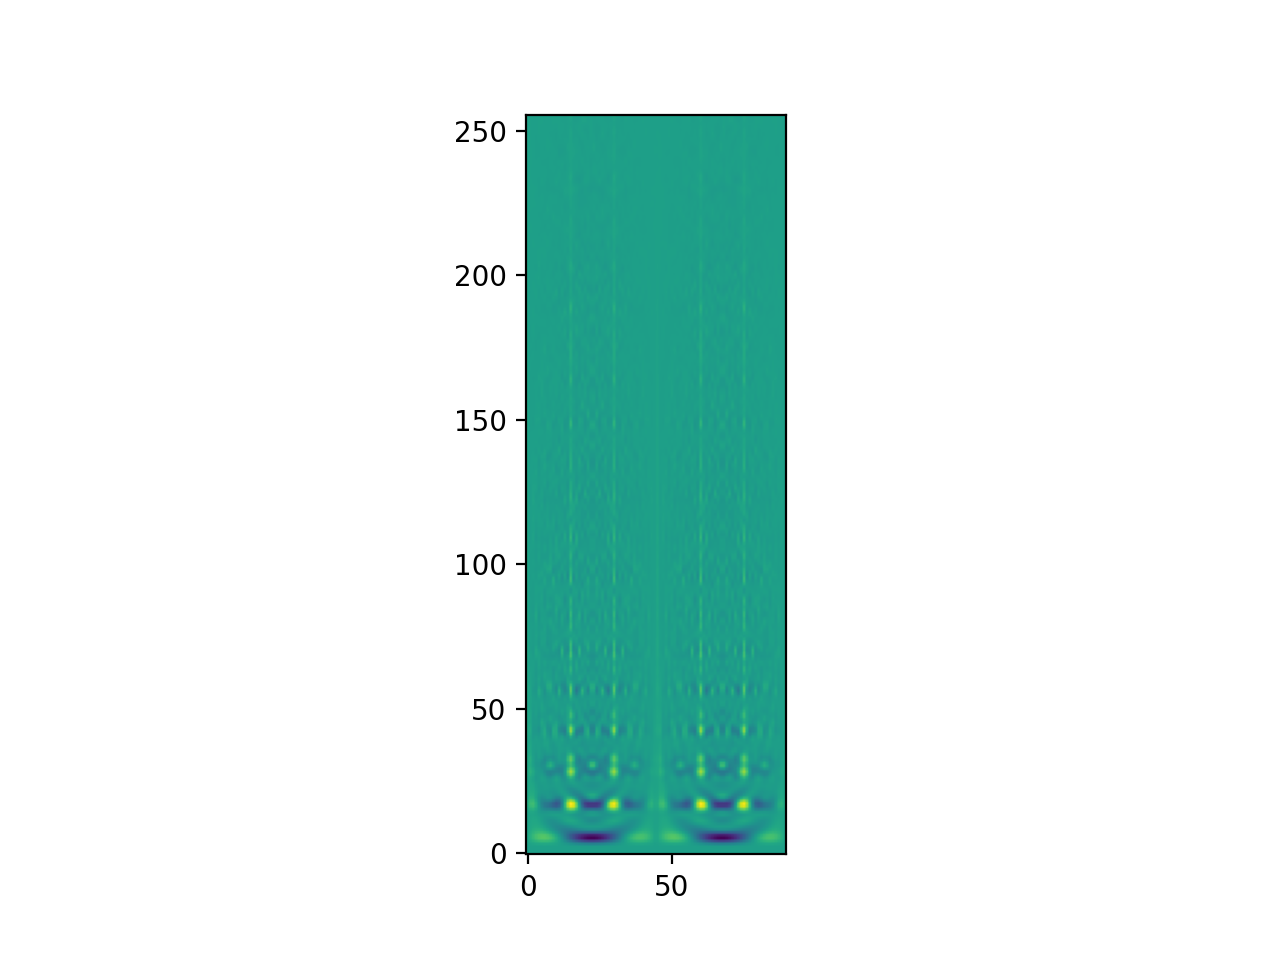

2.3937019398364953e-08 -1.1533049270446718e-08


In [10]:
ab = "a"
ctag = tag+"_"+ab
configfile = pstr( configpath, "config_hex_corrplot.txt")
corrfile = pstr( padfoutpath , ctag+"_correlation_sum.npy")
suffix = "_test"
submean = "True"
sintheta= "False"
power = 0

flags = f'--stype reqr --outpath {pstr(padfoutpath)} --fname {corrfile} --suffix {suffix} --sintheta {sintheta} --submean {submean} --power {power}'
result = subprocess.run(f'python ./plotfxs3d.py -c {configfile} '+flags,shell=True) 
image = np.load(corrfile[:-4]+"_"+suffix+"_reqr.npy")
plt.imshow(image*1e100, origin='lower')
print(np.max(image), np.min(image))

### STEP 4.3: Mask the correlation function
#### This step can be used to exclude parts of the correlation data affected by artefacts
#### Even if no q-regions or theta-regions are excluded this is necessary to multiply by a sin\theta term

In [17]:
ablist = ["a","b"]
qmin, qmax = 0.0, 15.82
qmasklow, qmaskhigh = 0.01, 15.81
for ab in ablist:
    tag2 = tag+"_"+ab
    corrfile = pstr(padfoutpath, tag2+"_correlation_sum.npy")
    configfile = pstr( configpath, "config_hex_mask.txt")
    flags = f"--outpath {padfoutpath} --corrfile {corrfile}"
    flags += f" --qmin {qmin} --qmax {qmax} --qmasklow {qmasklow} --qmaskhigh {qmaskhigh}"
    result = subprocess.run( f"python ./maskcorr.py --config {configfile} "+flags, shell=True)


maskcorr.py
pypadf version  0.5.2

config file name: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/configs/config_hex_mask.txt
Correlation loaded: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output/hex_a_correlation_sum.npy
Output file:  /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output/hex_a_correlation_sum_sintheta.npy
maskcorr.py
pypadf version  0.5.2

config file name: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/configs/config_hex_mask.txt
Correlation loaded: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output/hex_b_correlation_sum.npy
Output file:  /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output/hex_b_correlation_sum_sintheta.npy


### STEP 4.4: Check the masked correlation function


In [18]:
ab = "b"
ctag = tag+"_"+ab
corrfile = pstr(padfoutpath, ctag+"_correlation_sum_sintheta.npy")
configfile = pstr( configpath, "config_hex_corrplot.txt")
suffix = "_masktest"

flags = f'--stype reqr --outpath {pstr(padfoutpath)} --fname {corrfile} --suffix {suffix}'
result = subprocess.run(f'python ./plotfxs3d.py -c {configfile} '+flags,shell=True) 
image = np.load(corrfile[:-4]+"_"+suffix+"_reqr.npy")
plt.imshow(image, origin='lower')
print( image.shape)

pypadf version  0.5.2
 

config file name: /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/configs/config_hex_corrplot.txt
Plotting : /Users/andrewmartin/cloudstor/Work/Research/SF/codes/code_projects/pypadf/demo/jupyter-results/hex/padf_output/hex_b_correlation_sum_sintheta.npy
Dimensions : (256, 256, 90)
Section extracted : reqr
Figure(640x480)
(256, 90)


### STEP 6: Calculate the PADFs ! :)

In [ ]:
suffix = "_nlmin4_nl64_4"
ablist = ["a", "b"]
#qmax = 2.016e10*(0.3/(dz*0.001))   #RMMF calibration
qmax = 1279685560.2782264
for ab in ablist:
    tag2 = tag+"_"+ab

    corrfile = pstr(padfoutpath, tag2+"_correlation_sum_sintheta.npy")

    configfile = pstr( configpath, "config_hex_padf.txt")

    newtag = tag+suffix+"_"+ab
    flags = f"--outpath {pstr(padfoutpath)} --corrfile {corrfile} --tag {newtag} --qmax {qmax}"
    result = subprocess.Popen( f"python ./corrtopadf.py --config {configfile} "+flags, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, shell = True)
    for line in result.stdout: print(line,end="")
    result.wait()

# This final part creates an a + b PADF
suffix = "_nlmin4_nl64_4"
padftag = sample+suffix+"_"+"a"
corrfile = pstr(padfoutpath,padftag+"_padf.npy")
corrA = np.load(corrfile)
padftag = sample+suffix+"_"+"b"
corrfile = pstr(padfoutpath, padftag+"_padf.npy")
corrB = np.load(corrfile)

padftag = sample+suffix+"_"+"ab"
corrfile = pstr(padfoutpath,padftag+"_padf.npy")
np.save(corrfile, 0.5*(corrA+corrB)) 

### Plot the PADF

In [ ]:
suffix = "_nlmin4_nl64_4"
ab = "ab"
padftag = sample+suffix+"_"+ab
corrfile = pstr(padfoutpath, padftag+"_padf.npy")
print(corrfile)
configfile = pstr( configpath, "config_hex_plot.txt")

convolve = False
rwid = 0.4
thwid = 10
rval = 5.3
rpval = 5.3
thval = 90
thmaxdisp = 180
power = 2
flags = f'--stype reqr --outpath {pstr(padfoutpath)} --fname {corrfile} --suffix {suffix} --convolve {convolve} --rwid {rwid} --thwid {thwid} --power {power}'
result = subprocess.run(f'python ./plotfxs3d.py -c {configfile} '+flags,shell=True) 
image = np.load(corrfile[:-4]+"_"+suffix+"_reqr.npy")
s = image.shape
plt.figure()
plt.imshow(image[20:,:s[1]//2], origin='lower',aspect=15,extent=[0,180,0,16])
plt.show()
